# Evaluacion Final v2 — Modelos Optimizados Anti-Overfitting

**Objetivo:** Evaluar los 5 modelos con los hiperparametros optimos de `grid_search_optimization.ipynb` v2.

**Estructura:**
1. **Parte 1** — `classification_report`, matrices de confusion, probabilidades via `cross_val_predict` sobre `training.csv`.
2. **Parte 2** — Predicciones finales sobre `test.csv` + diagnostico de overfitting + importancia de variables.

**Cambios v2:**
- Pipeline hibrido: SMOTE controlado ({2:300}) + class_weight + SelectKBest
- Scoring optimizado con `f1_macro`

> **IMPORTANTE**: Actualizar los hiperparametros de cada modelo con los resultados
> del GridSearchCV v2 tras ejecutarlo. Los valores actuales son placeholders.

## 1. Importaciones y configuracion global

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif

# Modelos
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Metricas
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Configuracion global
SEED = 42
CV_FOLDS = 5
SMOTE_STRATEGY = {2: 300}
np.random.seed(SEED)

cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

print('Imports OK')

Imports OK


## 2. Carga de datos

In [2]:
train_df = pd.read_csv('data/training.csv', index_col=0)
test_df  = pd.read_csv('data/test.csv', index_col=0)

cols_to_drop = ['bpsmt', 'csuhz', 'gwrec', 'glhls', 'bqwyz']
TARGET = 'class'

X_train = train_df.drop(columns=[TARGET] + cols_to_drop)
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET] + cols_to_drop)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'\nDistribucion de clases (train):')
print(y_train.value_counts().sort_index())

X_train: (3000, 45), y_train: (3000,)
X_test:  (2000, 45)

Distribucion de clases (train):
class
0    2060
1     921
2      19
Name: count, dtype: int64


## 3. Definicion de modelos optimizados

Pipeline hibrido v2: SMOTE controlado + SelectKBest + class_weight donde aplique.

> **NOTA**: Actualizar `k` y los hiperparametros del clasificador con los resultados
> del `GridSearchCV` v2 (seccion 6 de `grid_search_optimization.ipynb`).

> **SVM**: Se activa `probability=True` para permitir `predict_proba` en la seccion
> de distribucion de probabilidades.

In [3]:
# TODO: Actualizar hiperparametros tras ejecutar GridSearchCV v2

models = {
    'Random Forest': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=SMOTE_STRATEGY, random_state=SEED)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=25)),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            max_depth=20,
            max_features='sqrt',
            class_weight='balanced',
            random_state=SEED,
        )),
    ]),

    'Gradient Boosting': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=SMOTE_STRATEGY, random_state=SEED)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=45)),
        ('classifier', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            random_state=SEED,
        )),
    ]),

    'AdaBoost': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=SMOTE_STRATEGY, random_state=SEED)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
        ('classifier', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=200,
            learning_rate=1.0,
            random_state=SEED,
        )),
    ]),

    'SVM (RBF)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=SMOTE_STRATEGY, random_state=SEED)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=25)),
        ('classifier', SVC(
            kernel='rbf',
            C=1,
            gamma=0.1,
            class_weight='balanced',
            probability=True,
            random_state=SEED,
        )),
    ]),

    'Bagging': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=SMOTE_STRATEGY, random_state=SEED)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
        ('classifier', BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced'),
            n_estimators=100,
            max_samples=1.0,
            random_state=SEED,
        )),
    ]),
}

print(f'Modelos definidos: {list(models.keys())}')


Modelos definidos: ['Random Forest', 'Gradient Boosting', 'AdaBoost', 'SVM (RBF)', 'Bagging']


---
## PARTE 1: Evaluacion con Validacion Cruzada (`training.csv`)

Se usa `cross_val_predict` para obtener predicciones **fuera de fold** (out-of-fold) para cada
observacion del training. Esto permite generar `classification_report` y matrices de confusion
sin data leakage.

### 4. Classification Report por modelo

In [4]:
cv_predictions = {}
cv_times = {}

for name, pipe in models.items():
    print(f'\n{"=" * 60}')
    print(f'  {name}')
    print(f'{"=" * 60}')

    start = time.time()
    y_pred_cv = cross_val_predict(
        pipe, X_train, y_train,
        cv=cv_strategy,
        n_jobs=-1,
    )
    elapsed = time.time() - start

    cv_predictions[name] = y_pred_cv
    cv_times[name] = round(elapsed, 1)

    print(f'  Tiempo de computo: {elapsed:.1f}s')
    print(classification_report(
        y_train, y_pred_cv,
        target_names=['Clase 0', 'Clase 1', 'Clase 2'],
        zero_division=0,
    ))


  Random Forest
  Tiempo de computo: 19.7s
              precision    recall  f1-score   support

     Clase 0       0.76      0.87      0.81      2060
     Clase 1       0.58      0.41      0.48       921
     Clase 2       0.00      0.00      0.00        19

    accuracy                           0.72      3000
   macro avg       0.45      0.43      0.43      3000
weighted avg       0.70      0.72      0.71      3000


  Gradient Boosting
  Tiempo de computo: 68.8s
              precision    recall  f1-score   support

     Clase 0       0.78      0.89      0.83      2060
     Clase 1       0.64      0.44      0.52       921
     Clase 2       0.00      0.00      0.00        19

    accuracy                           0.75      3000
   macro avg       0.47      0.44      0.45      3000
weighted avg       0.73      0.75      0.73      3000


  AdaBoost
  Tiempo de computo: 2.1s
              precision    recall  f1-score   support

     Clase 0       0.74      0.88      0.80      2060

### 5. Matrices de Confusion Absolutas

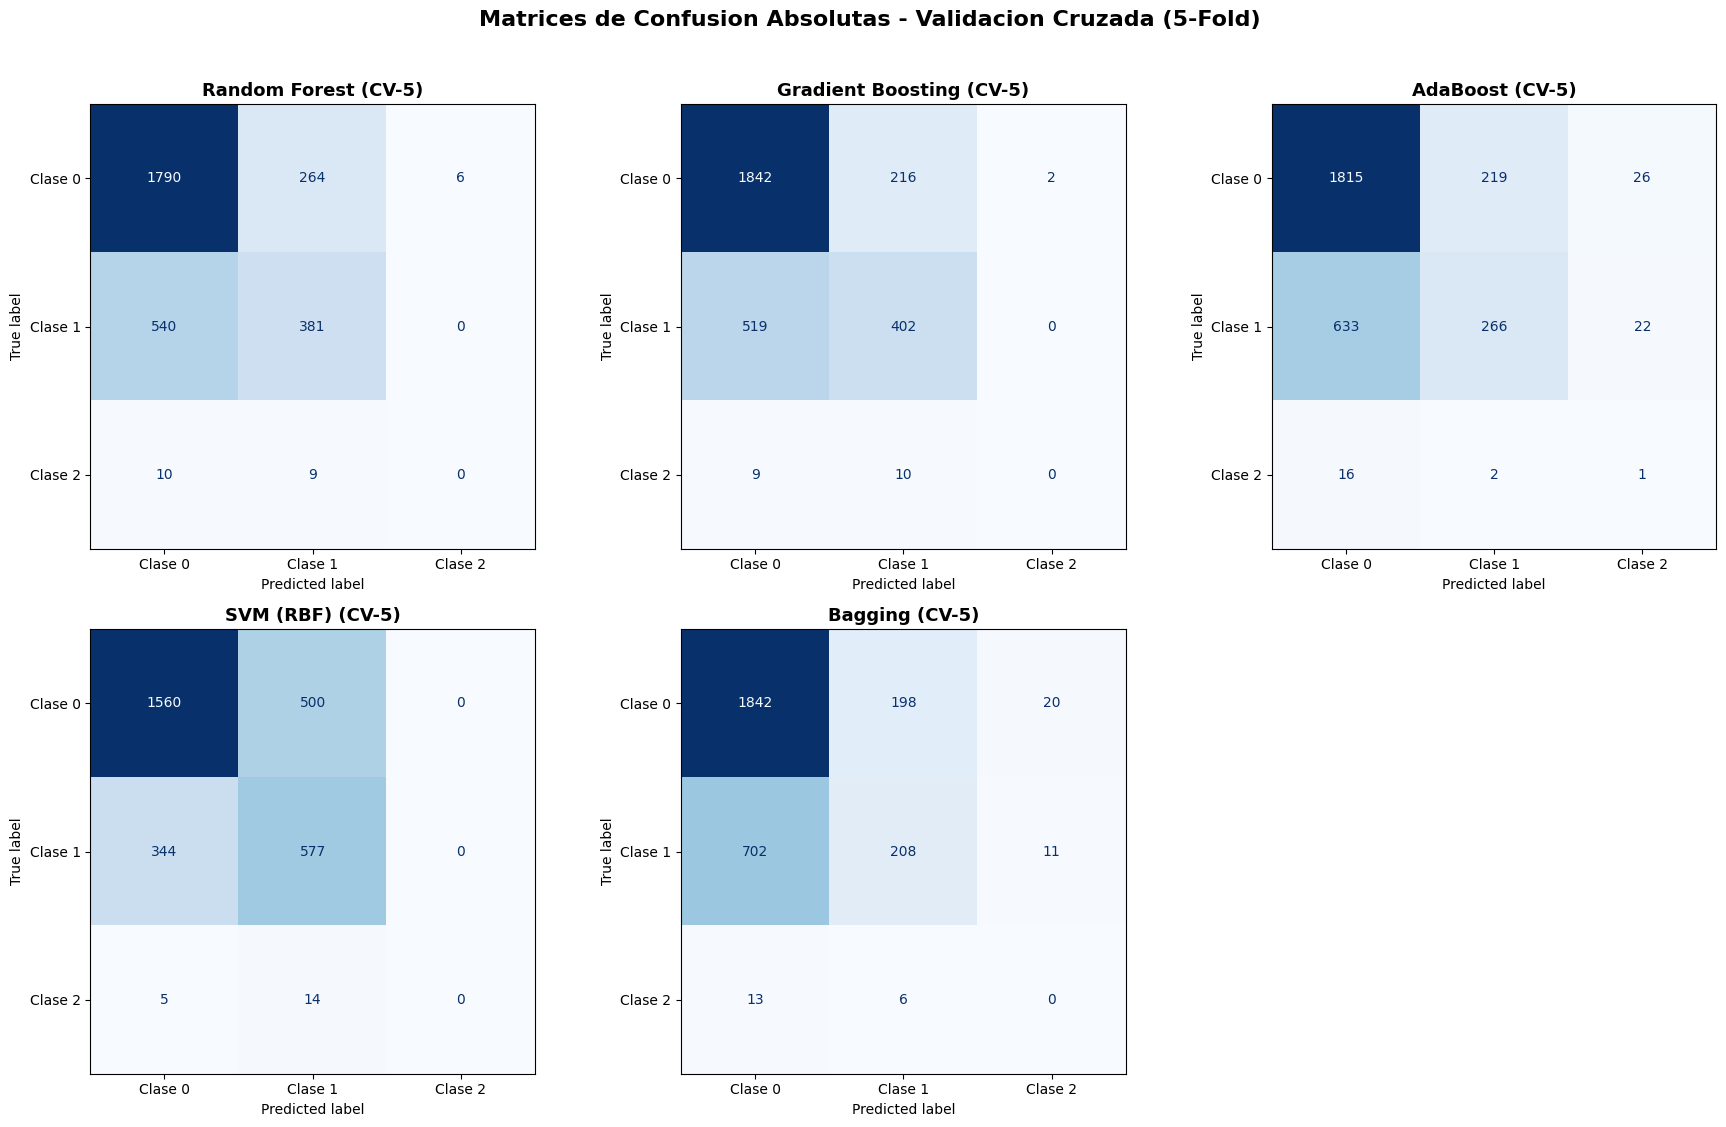

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (name, y_pred_cv) in enumerate(cv_predictions.items()):
    cm = confusion_matrix(y_train, y_pred_cv)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Clase 0', 'Clase 1', 'Clase 2'],
    )
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False, values_format='d')
    axes[idx].set_title(f"{name} (CV-5)", fontsize=13, fontweight='bold')

axes[-1].set_visible(False)

fig.suptitle(
    'Matrices de Confusion Absolutas - Validacion Cruzada (5-Fold)',
    fontsize=16, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig('data/matrices_confusion_cv.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Resumen: Metricas de Clase 2 (la minoritaria)

Tabla comparativa del impacto de la estrategia hibrida (SMOTE controlado + class_weight + SelectKBest).

In [ ]:
class2_metrics = []
for name, y_pred_cv in cv_predictions.items():
    report = classification_report(
        y_train, y_pred_cv,
        target_names=['Clase 0', 'Clase 1', 'Clase 2'],
        output_dict=True,
        zero_division=0,
    )
    c2 = report['Clase 2']
    class2_metrics.append({
        'Modelo': name,
        'Precision (C2)': round(c2['precision'], 4),
        'Recall (C2)': round(c2['recall'], 4),
        'F1-Score (C2)': round(c2['f1-score'], 4),
        'Support (C2)': int(c2['support']),
        'Accuracy Global': round(report['accuracy'], 4),
        'F1-Macro': round(f1_score(y_train, y_pred_cv, average='macro', zero_division=0), 4),
        'Tiempo (s)': cv_times[name],
    })

class2_df = pd.DataFrame(class2_metrics).sort_values('F1-Score (C2)', ascending=False)
display(class2_df)

### 7. Distribucion de Probabilidades Predichas (SVM RBF)

Analisis visual de como el desbalanceo extremo sesga los umbrales de decision.
Se usa `cross_val_predict` con `method='predict_proba'` para obtener probabilidades
fuera de fold.

> **Nota**: Requiere `probability=True` en la definicion del SVC (activado en seccion 3).

In [ ]:
# Obtener las probabilidades fuera de pliegue para la SVM
print('Calculando probabilidades OOF para SVM (RBF)...')
y_probas_svm = cross_val_predict(
    models['SVM (RBF)'], X_train, y_train,
    cv=cv_strategy, n_jobs=-1, method='predict_proba'
)
print(f'Shape de probabilidades: {y_probas_svm.shape}')

# Graficar la distribucion de la probabilidad asignada a la Clase 2
plt.figure(figsize=(10, 5))
plt.hist(
    y_probas_svm[:, 2], bins=50,
    color='crimson', alpha=0.7, edgecolor='black',
    label='Probabilidad Clase 2'
)
plt.axvline(
    x=0.5, color='black', linestyle='--', linewidth=1.5,
    label='Umbral Estandar (0.5)'
)

plt.title(
    'Distribucion de Probabilidades Predichas para la Clase Minoritaria (SVM RBF)',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Probabilidad Asignada por el Modelo a la Clase 2')
plt.ylabel('Numero de Muestras (Frecuencia)')
plt.yscale('log')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('data/distribucion_probabilidades_svm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## PARTE 2: Predicciones Finales sobre `test.csv`

Se entrena cada modelo con **todo** el `training.csv` y se generan las predicciones
sobre `test.csv` (el examen sin etiquetas).

### 8. Entrenamiento final y prediccion

In [ ]:
predictions_test = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)
    predictions_test[name] = y_pred_test

    dist = pd.Series(y_pred_test).value_counts().sort_index()
    print(f'\n{name} - Distribucion de predicciones en test:')
    for cls, count in dist.items():
        print(f'   Clase {cls}: {count} ({count / len(y_pred_test) * 100:.1f}%)')

### 9. Control de Overfitting: Brecha Train vs CV

Verificamos la brecha real entre las metricas sobre el propio training (memorizacion)
y las metricas de cross-validation (generalizacion).

In [ ]:
print(f"{'Modelo':<22} {'Train Acc':>10} {'Train F1m':>10} {'CV F1m':>10} {'Brecha':>10}")
print('=' * 65)

for name, pipe in models.items():
    train_preds = pipe.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    train_f1m = f1_score(y_train, train_preds, average='macro', zero_division=0)

    cv_f1m = f1_score(y_train, cv_predictions[name], average='macro', zero_division=0)
    gap = train_f1m - cv_f1m

    print(f'{name:<22} {train_acc:>10.4f} {train_f1m:>10.4f} {cv_f1m:>10.4f} {gap:>+10.4f}')

### 10. Importancia de Variables (Feature Importance)

Coeficientes de importancia basados en la impureza de Gini del Random Forest reajustado.

> **Nota tecnica**: Al usar `SelectKBest` en el pipeline, el clasificador solo ve las `k`
> variables seleccionadas. Se mapean de vuelta a los nombres originales del dataset.

In [ ]:
# Extraer componentes del pipeline de Random Forest (ya ajustado en seccion 8)
rf_pipe = models['Random Forest']
selector = rf_pipe.named_steps['feature_selection']
rf_model = rf_pipe.named_steps['classifier']

# Mapear las k variables seleccionadas a sus nombres originales
selected_mask = selector.get_support()
selected_names = X_train.columns[selected_mask]

importances = rf_model.feature_importances_

# Crear DataFrame y ordenar
feat_df = pd.DataFrame({'Variable': selected_names, 'Importancia': importances})
feat_df = feat_df.sort_values('Importancia', ascending=False).head(15)

print(f'Variables seleccionadas por SelectKBest: {len(selected_names)}')
print(f'Top 15 por Gini Importance:')

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(
    feat_df['Variable'][::-1],
    feat_df['Importancia'][::-1],
    color='steelblue', edgecolor='black'
)
plt.title(
    'Top 15 Variables Mas Criticas (Random Forest - Gini Importance)',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Importancia Relativa')
plt.ylabel('Atributos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('data/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. Guardar predicciones

In [ ]:
predictions_df = pd.DataFrame(
    predictions_test,
    index=test_df.index,
)
predictions_df.to_csv('data/predicciones_test.csv')
print('Predicciones guardadas: data/predicciones_test.csv')
display(predictions_df.head(10))